In [1]:
import os
import numpy as np
import pandas as pd
import librosa
from tqdm import tqdm

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
DATA_PATH = r"D:\Test 1\dataset\ASVspoof2019_LA_train\flac"
PROTOCOL_PATH = r"D:\Test 1\dataset\ASVspoof2019_LA_train\train_protocol.txt"

In [4]:
def extract_mfcc(file_path):
    y, sr = librosa.load(file_path, sr=16000)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)

    if mfcc.shape[1] < 157:
        pad = 157 - mfcc.shape[1]
        mfcc = np.pad(mfcc, ((0,0),(0,pad)))
    else:
        mfcc = mfcc[:, :157]

    return mfcc

In [5]:
df = pd.read_csv(PROTOCOL_PATH, sep=" ", header=None)
df.columns = ["speaker", "file", "x1", "x2", "label"]

df["label"] = df["label"].map({"bonafide": 1, "spoof": 0})

In [6]:
X, y = [], []

for _, row in tqdm(df.iterrows(), total=len(df)):
    path = os.path.join(DATA_PATH, row["file"] + ".flac")

    if not os.path.exists(path):
        continue

    try:
        mfcc = extract_mfcc(path)
        X.append(mfcc)
        y.append(row["label"])
    except:
        continue

X = np.array(X)
y = to_categorical(y, 2)

X = X.reshape(-1, 40, 157, 1)

100%|██████████| 5000/5000 [01:03<00:00, 79.28it/s] 


In [7]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

In [8]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(40,157,1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(2, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

c:\Users\Hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.8225 - loss: 0.7125 - val_accuracy: 0.9100 - val_loss: 0.2264
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9405 - loss: 0.1669 - val_accuracy: 0.9200 - val_loss: 0.2020
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9585 - loss: 0.1134 - val_accuracy: 0.9250 - val_loss: 0.1866
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9710 - loss: 0.0815 - val_accuracy: 0.9720 - val_loss: 0.0957
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9820 - loss: 0.0549 - val_accuracy: 0.9090 - val_loss: 0.3526
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9778 - loss: 0.0605 - val_accuracy: 0.9430 - val_loss: 0.1388
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9847 - loss: 0.0424 - val_accuracy: 0.9690 - val_loss: 0.1073


In [10]:
os.makedirs("models", exist_ok=True)
model.save("models/deepfake_model.keras")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


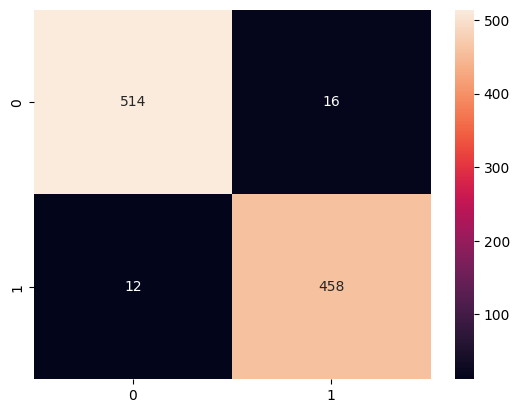

              precision    recall  f1-score   support

           0       0.98      0.97      0.97       530
           1       0.97      0.97      0.97       470

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000



In [11]:
y_pred = model.predict(X_val)
y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_val, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

print(classification_report(y_true, y_pred))

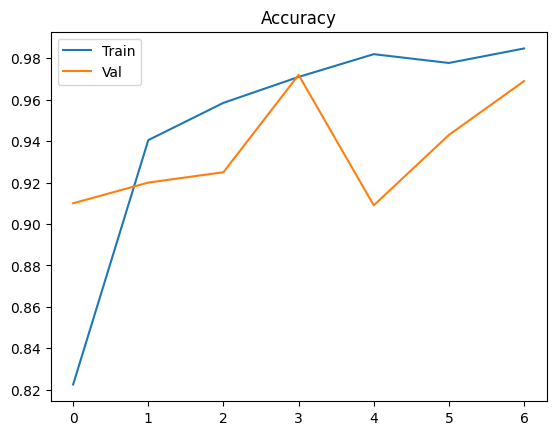

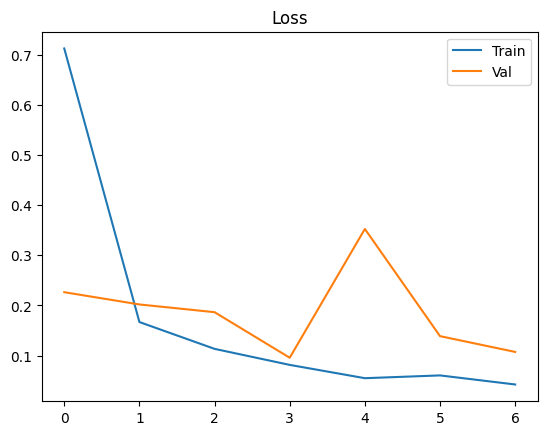

In [12]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train", "Val"])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train", "Val"])
plt.show()